In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file
file_path = "data/T1.csv"   # Change to your file name
df = pd.read_csv(file_path)

df['Date/Time'] = pd.to_datetime(
    df['Date/Time'],
    format='%d %m %Y %H:%M',
    errors='coerce'
)

# Filter rows for the selected month and year
df = df[
    (df['Date/Time'].dt.month == 7)
]

# =======================================
# Detect and Handle Missing/Null Values
# =======================================

# Fill missing values automatically
for column in df.columns:

    # If numeric column → fill with mean
    if pd.api.types.is_numeric_dtype(df[column]):
        df[column] = df[column].fillna(df[column].mean())

    # If text column → fill with mode
    else:
        df[column] = df[column].fillna(df[column].mode()[0])

# =======================================
# Remove Duplicate Records
# =======================================
df = df.drop_duplicates()

# =======================================
# Correct Corrupted Data Types
# =======================================

# Try converting object columns into numeric if possible
for column in df.columns:

    if df[column].dtype == "object":

        # Remove unwanted spaces
        df[column] = df[column].astype(str).str.strip()

        # Attempt numeric conversion
        converted = pd.to_numeric(df[column], errors='coerce')

        # If many values successfully convert, replace column
        if converted.notnull().sum() > len(df[column]) * 0.5:
            df[column] = converted



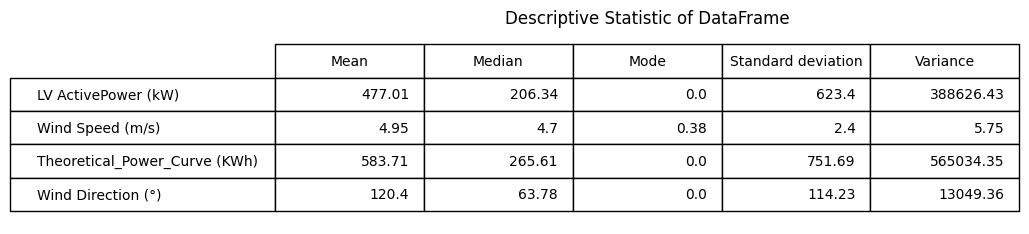

In [9]:
# =======================================
# Descriptive Statistics
# =======================================

columns = [
    "LV ActivePower (kW)",
    "Wind Speed (m/s)",
    "Theoretical_Power_Curve (KWh)",
    "Wind Direction (°)"
]

data = []
for column in columns:
    if column not in df.columns:
        continue
    series = df[column]
    data.append([
        round(series.mean(), 2),
        round(series.median(), 2),
        round(series.mode().iloc[0] if not series.mode().empty else np.nan, 2),
        round(series.std(), 2),
        round(series.var(), 2)
    ])

fig, ax = plt.subplots(figsize=(6, 2.5))
plt.title("Descriptive Statistic of DataFrame")
ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=data,
    rowLabels=columns,
    colLabels=["Mean", "Median", "Mode", "Standard deviation", "Variance"],
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.6, 2)

plt.savefig(
    "outputs/Descriptive Statistic of DataFrame.png",
    bbox_inches='tight',
)

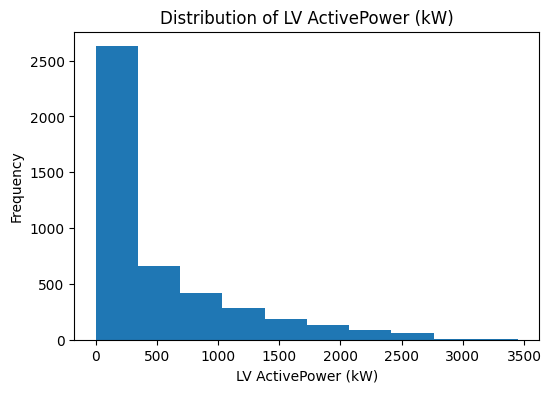

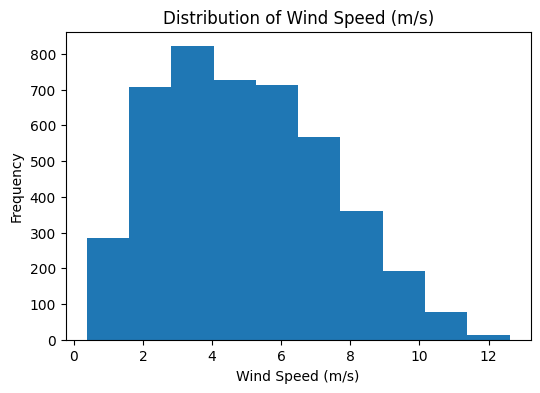

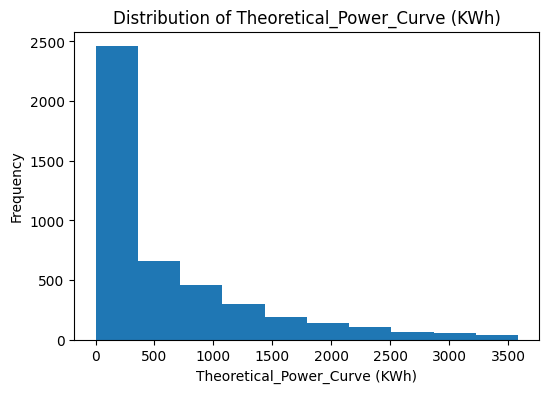

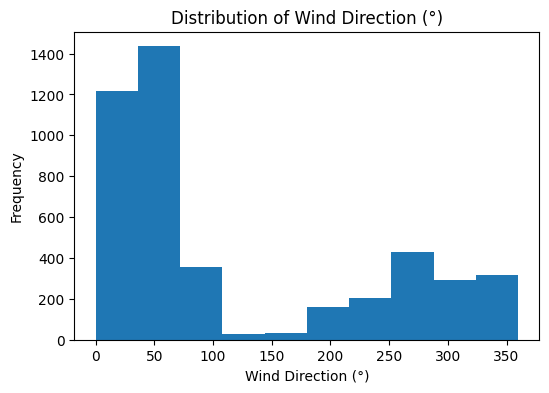

In [10]:
# =======================================
# Distribution Analysis
# =======================================

for col in columns:
    if col not in df.columns:
        print(f"Column '{col}' not found.")
        continue

    # Plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=10)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    # Save each plot as PNG
    if col == "Wind Speed (m/s)":
        col = col.replace("/", " per ")
    plt.savefig(f"outputs/distribution_{col}.png", dpi=300, bbox_inches='tight')



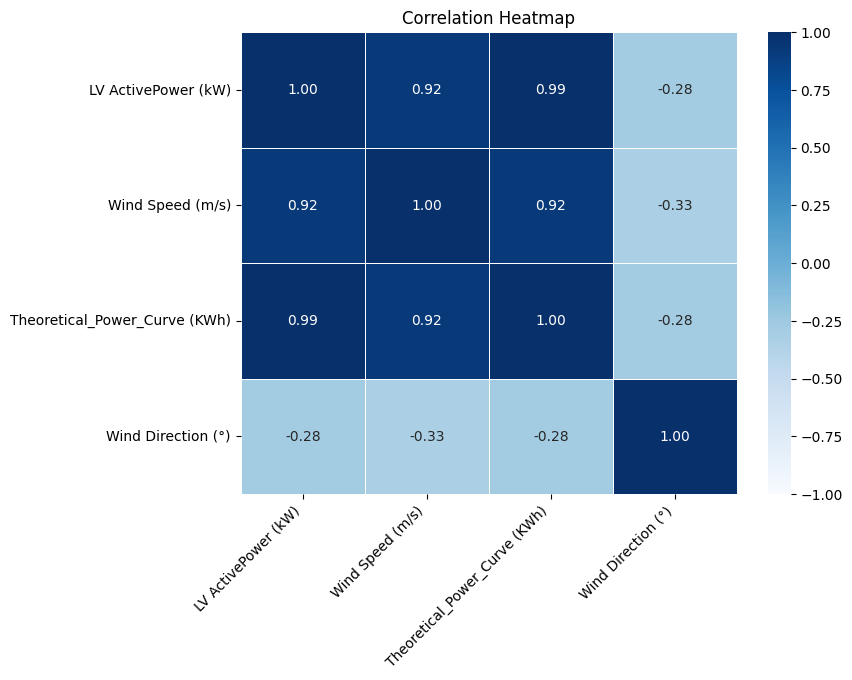

In [11]:
# =======================================
# Corrolation Analysis
# =======================================

# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Heatmap")

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Save as PNG
plt.savefig("outputs/correlation_heatmap.png", dpi=300, bbox_inches="tight")


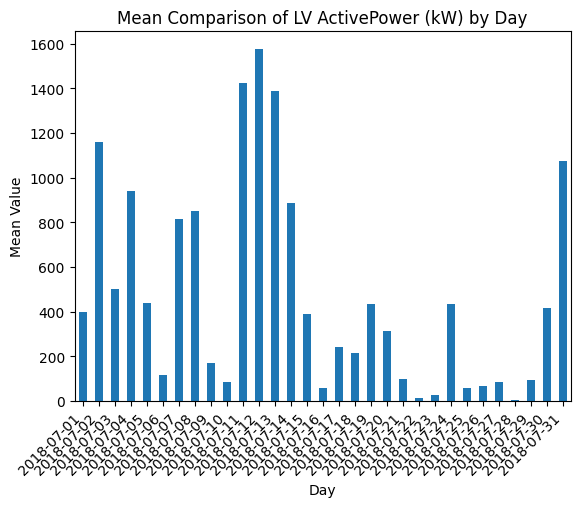

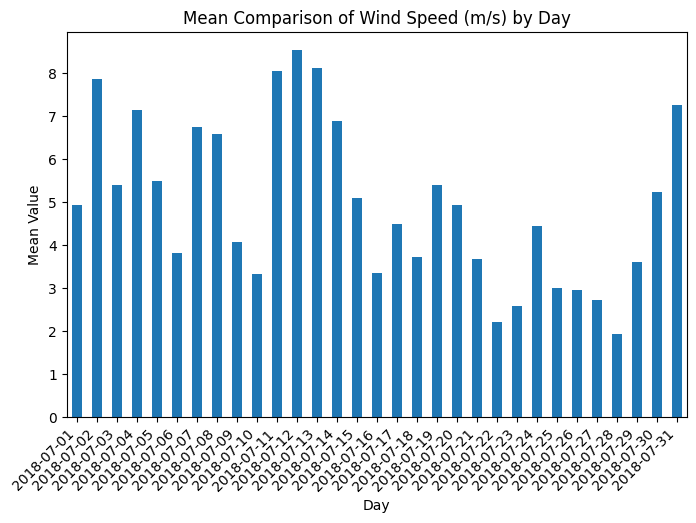

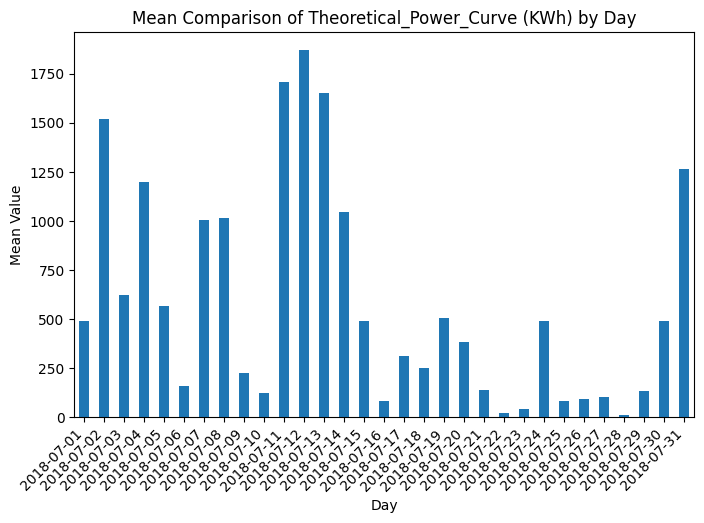

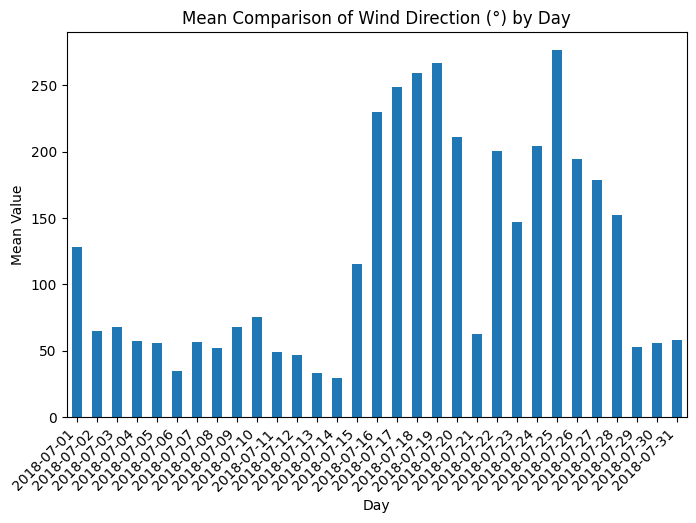

<Figure size 800x500 with 0 Axes>

In [13]:
# =======================================
# Comparative Analysis
# =======================================

df['Day'] = df['Date/Time'].dt.date     

category_col = "Day"
grouped = df.groupby(category_col)[columns].mean()

for col in columns:
    grouped[col].plot(kind="bar")

    plt.title(f"Mean Comparison of {col} by {category_col}")
    plt.xlabel(category_col)
    plt.ylabel("Mean Value")

    plt.xticks(rotation=45, ha='right')

    # Save chart
    if col == "Wind Speed (m/s)":
        col = col.replace("/", " per ")
    plt.figure(figsize=(8, 5))
    plt.savefig(f"outputs/Mean Comparison of {col} by {category_col}.png", dpi=300, bbox_inches='tight')
